# An AI Calorie Tracker

### Overview
Calorie Tracker app uses AI vision to identify food from uploaded images and estimates its nutritional information!

### Learning Objectives
- Communicate with AI Vision Models, using API.
- Prompt Engineering, including context, instruction, input, and output indicator
- Understand the difference between zero-shot, few-shot and chain-of-thoughts prompting.
- Discover how to convert an image into a base64-encoded string for OpenAI API calls.

### Packages used for the project, installaion and imports

In [1]:
!pip install --upgrade openai
from openai import OpenAI
import os

from dotenv import load_dotenv


Could not import runpy._run_module_as_main
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1342, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 938, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1179, in exec_module
  File "<frozen runpy>", line 14, in <module>
  File "C:\Users\Paco_Minha\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\__init__.py", line 57, in <module>
    import warnings
  File "C:\Users\Paco_Minha\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\warnings.py", line 591, in <module>
    filterwarnings("default", category=DeprecationWarning,
  File "C:\Users\Paco_Minha\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\warnings.py", line 155, in filterwarnings
    import re
  File "C:\Users\Paco_Minha\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\re\__init__.py"

In [3]:
load_dotenv()

#  Get the OpenAI API keys from Environment Variables
openai_api_key = os.getenv("OPENAI_API_KEY")

# Configure the OpenAI client/instance using api key
openai_client = OpenAI(api_key= openai_api_key)
print("OpenAI API key successfuuly configured.")

# Print first few characters in the key
print(f"OpenAI API KEY : {openai_api_key[:10]}")

OpenAI API key successfuuly configured.
OpenAI API KEY : sk-proj-3Z


In [4]:
# Define a helper function named "print_markdown" to display markdown
from IPython.display import display, Markdown

def print_markdown(text):
    """
    Displays text as mrkdown in cell output
    """
    display(Markdown(text))

In [5]:
# Let's try loading and displaying a sample image
# Before sending images to OpenAI/Model, we need to lear how to load and view them in our notebook
# We'll use the Pillow library (imported as PIL) for this task
from PIL import Image

Image `images/food2.jfif loaded successfully
Format: JPEG
Size: (275, 184)
Mode: RGB


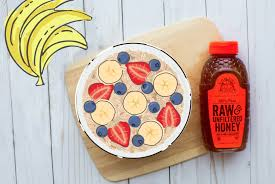

In [7]:
# Make sure the image file is in the same diretory as the notebook, or provide exact address.
image_file_path = "images/food2.jfif"

img = Image.open(image_file_path)
print(f"Image `{image_file_path} loaded successfully")
print(f"Format: {img.format}")
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")

# Use Ipython.display to show the image directly in the notebook output.
display(img)

# keep the loaded image object in a variable for later use
image_to_analyze= img


### Understand Prompt Engineering Fundamentals

- Prompt Engineering is the practice of designing and optimizing text input to generative AI models to obtain desired responses.
- It is the art of communicating with a generative model.
- High Quality prompts guide the AI model to generate better outputs.
    - "Recommend a book"
    - "Recommend a fiction book"
    - "Recommend a historical fiction book set in World War II."

#### Prompt components
- `Context` : Background knowledge to help the model understand the problem.
- `Instruction` : A clear statement of the  desired goal.
- `Input Data` : The Data the model needs to process to produce.
- `Output Indicator` : Tells the model the format of the output.

-----
    - Assume that you are an expert financial analyst. --> `Context`
    - Classify the follwoing text as positive, negative, or neutral. --> `Instruction`
    - Text: "Apple stock increased by 2% in today's trading session --> `Input Data`
    - Sentiment: `Output Indicator`.
-----

#### Prompt Engineering Techniques: Zero-Shot Prompting
- Refers to the ability of a generative AI model to generate responses without being provided with any prior examples.
- The model relies on its broad general knowledge learned from its training data to complete task.
    - Examples:  
        - "Tell me the sentiment of the following headline and categorize it as either positive, negative, or neutral"
        - "New Airline between Seatlle and San Francisco offers a great opportunity for both passengers and investors."

    - Output:
        - Positive
        - Positive 

#### Prompt Engineering Techniques: Few-Shot Prompting
- Involves the techniques, providing a few example pairs of input and desired output to the generative AI model to guide its response generation.
    - Examples:  
        - "Tell me the sentiment of the following. Here are some examples:
            Scenario: Apple Stock declined 2% today 
            Answer: Negative
            Scenario: Tesla stock gained 5% after successful self-driving demo
            Answer: Positive
            Scenario: OpenAI Expanded its userbase to 100 million
            Answer:
    - Output: 
        Positive
    

#### Promp Engineering Techniques: Chain-of Thoughts
- A technique that improves the reasoning abilities of AI models by breaking down complex questions or taks into smaller steps.
- It mimics how humans' reason and solve problems by systematically breaking down the decision-making process.

1. Standard prompt:
    Q: Sarah has 10 pencils, she gives 4 pencils and buys a pack of 5 more pencils. How many pencils does Sarah have now?
    Model Output:
        The answer is 11.
    Q: The library had 50 books. They lent 15 books to students and received 7 more books as a donation. How many books are in the library now?
    Model output: 
        The Answer is 57. (Wrong Answer)
2. Chain-of Though Prompting
    Q: Sarah has 10 pencils, she gives 4 pencils and buys a pack of 5 more pencils. How many pencils does Sarah have now?
    Model Output:
        Sarah started with 10 pencils, She gave away 4 pencils leaving her with 6. Then she bought 5 more prencils so 6 + 5 = 11. The Answer is 11
    Q: The library had 50 books. They lent 15 books to students and received 7 more books as a donation. How many books are in the library now?
    Model output: 
        The library started with 50 books, they lent 15 books so 50 - 15 = 35. Then, they received 7 more books so 35 + 7 = 42. The Answer is 42 (Correct Answer)

### Image Recognition using OpenAI's Vision API.

Send the loaded image to the vision Model and ask a simple question; 'what food is in this image'.  
OpenAI requires images to be sent either as a URL or as a base64-encoded string.  
We will use base64 encoding for local files. The image is part of the messages list.

In [8]:
# The io module in python provides tolls for working with streams of data
# Like reading from or writing to files in memory.
import io
# base64 used fo encoding images for OpenAI's API.
import base64

In [13]:
# Next step is to convert an image into a special text format (base64-encoded)
# This is used if we want to send an image to OpenAI's API
# Follwoing function works with two types of inputs:
# 1) A file path: a string that tells the function where the image is stored on your computer.
# 2) An image object: a photo already loaded in memory using the PIL library (Python Imaging Library)

def encode_image_to_base64(image_path_or_pil):
    if isinstance(image_path_or_pil, str): # if its a file path
        # check if the file exist.
        if not os.path.exists(image_path_or_pil):
            raise FileNotFoundError(f"Image file not found at: {image_path_or_pil}")
        with open(image_path_or_pil, 'rb') as image_file:
            return base64.b64encode(image_file.read()).decode('utf-8')
    elif isinstance(image_path_or_pil, Image.Image): # If it's a PIL Image Object
        buffer = io.BytesIO()
        image_format = image_path_or_pil.format or "JPEG"
        image_path_or_pil.save(buffer, format= image_format)
        return base64.b64encode(buffer.getvalue()).decode("utf-8")
    else:
        raise ValueError("Input must be a file path (str) or a PIL Image object.")

In [20]:
# Define a function that  queries OpenAI's vision model with an image 
def query_openai_vision(client, image, prompt, model = 'gpt-4o', max_tokens=500):
    """
    Function to quey OpenAI's vision model with an image

    Args:
        client: The OpenAI client
        image: PIL Image object to analyse
        prompt: Text prompt to send with the image
        model: OpenAI model to use (default: gpt-4o)
        max_tokens: Maximum tokens in response (default = 100)
    
    Returns:
        The modle's response text or an error image
    """

    # Encode the image to base64
    base64_image = encode_image_to_base64(image)

    try:
        # Construct the message payload
        messages = [
            {
                'role': 'user',
                'content' : [
                    {
                        'type': 'text',
                        'text' : prompt
                    },
                    {
                        'type': 'image_url',
                        'image_url' : {
                            'url' : f"data:image/jpeg;base64,{base64_image}"
                        },
                    },
                ],
            }
        ]
        

        # Make the API Call
        response = client.chat.completions.create(
            model = model,
            messages = messages,
            max_tokens = max_tokens
        )

        # Extract the response 
        return response.choices[0].message.content
    
    except Exception as e:
        return f"Error calling API: {e}"

In [21]:
# Text prompt that will be sent with the image
food_recognition_prompt = """
Context: I'm analyzing a food image for a calorie-tracking application.
Instruction: Plese identify the food item in this image.
Input: [The image I'm about to share]
Output: Provide the name of the food, a brief description of what you see, and if possible, mention its typical ingredients or nutritional profile.
"""

print(f"{food_recognition_prompt}")


Context: I'm analyzing a food image for a calorie-tracking application.
Instruction: Plese identify the food item in this image.
Input: [The image I'm about to share]
Output: Provide the name of the food, a brief description of what you see, and if possible, mention its typical ingredients or nutritional profile.



In [22]:
# Call the function and send it an image.
print("🤖 Querying OpenAI Vision...")
openai_description = query_openai_vision(
    openai_client,
    image_to_analyze,
    food_recognition_prompt
)

print_markdown(openai_description)

🤖 Querying OpenAI Vision...


The image shows a bowl of oatmeal topped with sliced bananas, strawberries, and blueberries. There is also a bottle of raw and unfiltered honey next to it, which suggests it might be used as a sweetener.

**Description:**
- **Food Item:** Oatmeal with fruit toppings.
- **Ingredients:** Typically includes oats, bananas, strawberries, blueberries, and honey.
- **Nutritional Profile:** Oatmeal is high in fiber and can help with digestion. The fruits add vitamins, antioxidants, and natural sugars, while honey provides additional sweetness.

This makes for a nutritious breakfast or snack option.

In [23]:
### Let's obtain the number of calories

In [24]:
# Update the structured prompt to ensure consistent model output
structured_nutrition_prompt = """
# Nutritional Analysis Task

## Content
You are a nutrition expert analyzing food images to provide accurate nutrition information.

## Instruction 
Analyze the food item in the image and provide estimated nutritional information based on your knowledge.

## Input
An image of a food item

## Output
Provide the following estimated nutritional information for a typical serving size or per 100g.
- food_name (string)
- serving_description (string, e.g., '1 slice', '100g', '1 cup')
- calories (float)
- fat_germs (float)
- protien_grams (float)
- confidence_level (string: 'High', 'Medium', or 'low')

**Important:** Respond ONLY with a single JSON object containing these fields. Do not include any other text, explanation, or applogies. The JSON keys must match exactly: "food_name", "serving_description", "calories", "fat_grams", "confidence_level". If you cannot estimate a value, use 'null'.

Example valid JSON response:
{
"food_name" : "Banana",
"serving_description" : "1 medium banana (approx 118g)",
"calories" : 105.0,
"fat_grams" : 0.4,
"protien_grams" : 1.3,
"confidence_level" : "High"
}
 
"""

In [25]:
# Let's call OpenAI API with the image and the new structured prompt
openaai_nutrition_results = query_openai_vision(
    client = openai_client,
    image = image_to_analyze,
    prompt= structured_nutrition_prompt
)

print_markdown(openaai_nutrition_results)

{
"food_name" : "Oatmeal with Fruits and Honey",
"serving_description" : "1 bowl (approx 200g)",
"calories" : 250.0,
"fat_grams" : 2.5,
"protien_grams" : 6.0,
"confidence_level" : "Medium"
}